#### The VGG16 model was developed by the Visual Graphics Group (VGG).
- **By default, the VGG-16 model expects color input images to be rescaled to the size of 224×224 squares.**

In [1]:
from keras.applications.vgg16 import VGG16
# load model
model = VGG16()
# summarize the model

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 113s 0us/step


In [14]:
import os

In [15]:
os.getcwd()

'C:\\Users\\pmgho'

In [16]:
os.chdir('C:\\Users\\pmgho\\OneDrive\\Desktop\\VGG-16\\image')

- **The model can then be used directly to classify a photograph into one of 1,000 classes.**

In [2]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

- **First, the photograph needs to loaded and reshaped to a 224×224 square, expected by the model, and the pixel values scaled in the way expected by the model. The model operates on an array of samples, therefore the dimensions of a loaded image need to be expanded by 1, for one image with 224×224 pixels and three channels.**

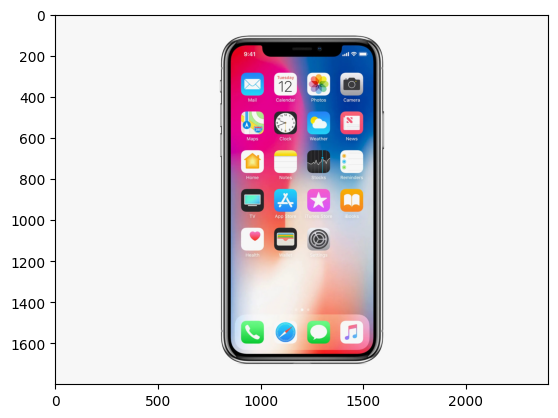

In [21]:
from keras.preprocessing.image import load_img
from keras.applications.imagenet_utils import preprocess_input
import numpy as np
# load an image from file
image = load_img(r'C:\\Users\\pmgho\\OneDrive\\Desktop\\VGG-16\\image\\phone.jpg', target_size=(224, 224))
# convert the image pixels to a numpy array
image = np.array(image)
# reshape data for the model
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
# prepare the image for the VGG model
image = preprocess_input(image)
image
my_image = imread('phone.jpg')
plt.imshow(my_image)

In [10]:
from matplotlib.image import imread

(-0.5, 2399.5, 1798.5, -0.5)

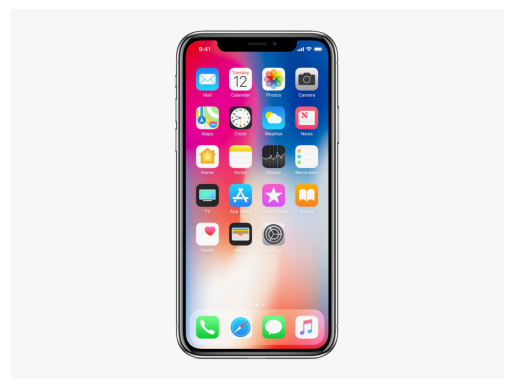

In [18]:
import matplotlib.pyplot as plt

my_image = imread(r'C:\\Users\\pmgho\\OneDrive\\Desktop\\VGG-16\\image\\phone.jpg')  # change path
plt.imshow(my_image)
plt.axis('off')

In [20]:
imread('phone.jpg')

array([[[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       ...,

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]],

       [[247, 247, 247],
        [247, 247, 247],
        [247, 247, 247],
        ...,
        [247, 247, 247],
        [247, 247, 247],
        [247, 247, 247]]

- **Next, the model can be loaded and a prediction made.**

- **This means that a predicted probability of the photo belonging to each of the 1,000 classes is made. In this example, we are only concerned with the most likely class, so we can decode the predictions and retrieve the label or name of the class with the highest probability.**

- ***predict the probability across all output classes***

In [23]:
y_pred = model.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


- ***convert the probabilities to class labels***

In [25]:
from keras.applications.vgg16 import preprocess_input, decode_predictions
label = decode_predictions(y_pred)
label

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step


[[('n04074963', 'remote_control', 0.9873838),
  ('n02992529', 'cellular_telephone', 0.0048336266),
  ('n04041544', 'radio', 0.00477453),
  ('n03485407', 'hand-held_computer', 0.001511876),
  ('n03584254', 'iPod', 0.00027778404)]]

- Ok Scientist Prajwal 